# Lista 7

## Imports

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC


## Zadanie 1

In [118]:
X, y = load_digits(return_X_y=True)

### Osobne komorki:m

<Axes: ylabel='Count'>

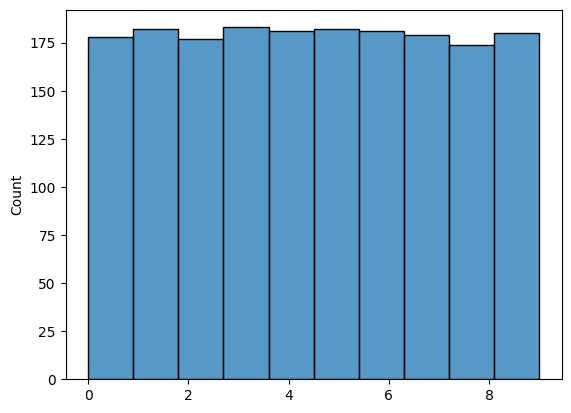

In [119]:
sns.histplot(y, bins=10)
# zbior jest zbalansowany

In [120]:
int(len(X) * 0.95)

1707

In [121]:
idx = np.random.choice(len(X), size=int(len(X) * 0.95), replace=False)
y_copy = y.copy()

In [122]:
y_copy[idx] = -1

<Axes: ylabel='Count'>

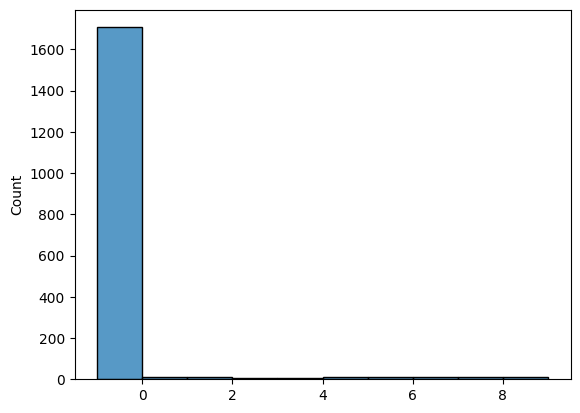

In [123]:
sns.histplot(y_copy, bins=10)

In [130]:
good_idx = np.where(y_copy != -1)
bad_idx = np.where(y_copy == -1)

In [124]:
kmeans = KMeans(10)
clusters = kmeans.fit_predict(X)

In [125]:
mapping = {}

for cluster_id in range(10):
    cluster_mask = (clusters == cluster_id)
    labeled_in_cluster = y_copy[cluster_mask & (y_copy != -1)]

    if len(labeled_in_cluster) > 0:
        unique, counts = np.unique(labeled_in_cluster, return_counts=True)
        most_common = unique[np.argmax(counts)]
        mapping[cluster_id] = most_common
    else:
        mapping[cluster_id] = -1

y_pred_vote = np.array([mapping[x] for x in clusters])

In [126]:
centroids = kmeans.cluster_centers_
clusters_without_labels = [c for c in range(10) if mapping[c] == -1]

for cluster_id in clusters_without_labels:
    distances = []
    labeled_clusters = [c for c in range(10) if mapping[c] != -1]

    for other_cluster in labeled_clusters:
        dist = np.linalg.norm(centroids[cluster_id] - centroids[other_cluster])
        distances.append((dist, other_cluster))

    if distances:
        _, closest_cluster = min(distances)
        mapping[cluster_id] = mapping[closest_cluster]

y_pred_close = np.array([mapping[x] for x in clusters])

In [142]:
y_bad, y_vote_bad, y_close_bad = y[bad_idx], y_pred_vote[bad_idx], y_pred_close[bad_idx]
print('Voting score: ', round(accuracy_score(y_bad, y_vote_bad), 3))
print('Close score: ', round(accuracy_score(y_bad, y_close_bad), 3))

Voting score:  0.722
Close score:  0.722


In [144]:
model = KNeighborsClassifier(5).fit(X[good_idx], y[good_idx])
preds = model.predict(X[bad_idx])
print("KNN score: ", round(accuracy_score(y_bad, preds), 3))

KNN score:  0.857


In [148]:
model = SVC(kernel='rbf', C=10).fit(X, y)
preds = model.predict(X[bad_idx])
print("SVM score:", round(accuracy_score(y_bad, preds), 3))

SVM score: 1.0


### Polaczony kod:

  Percentage  Voting  Closest    SVM
0         1%   0.605    0.610  0.614
1         5%   0.864    0.864  0.923
2        10%   0.860    0.860  0.934
3        20%   0.860    0.860  0.981


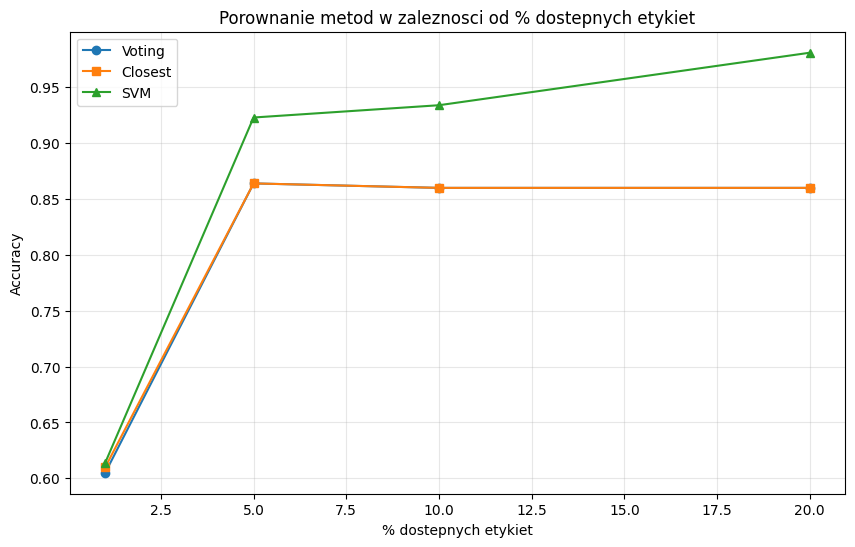

In [154]:
percentages = [0.01, 0.05, 0.10, 0.20]
results = []
rng = np.random.default_rng(42)

for pct in percentages:
    mask_size = int(len(X) * (1 - pct))
    idx = rng.choice(len(X), size=mask_size, replace=False)
    y_copy = y.copy()
    y_copy[idx] = -1

    good_idx = np.where(y_copy != -1)[0]
    bad_idx = np.where(y_copy == -1)[0]

    kmeans = KMeans(n_clusters=10, random_state=42)
    clusters = kmeans.fit_predict(X)

    mapping = {}
    for cluster_id in range(10):
        cluster_mask = (clusters == cluster_id)
        labeled_in_cluster = y_copy[cluster_mask & (y_copy != -1)]

        if len(labeled_in_cluster) > 0:
            unique, counts = np.unique(labeled_in_cluster, return_counts=True)
            mapping[cluster_id] = unique[np.argmax(counts)]
        else:
            mapping[cluster_id] = -1

    y_pred_vote = np.array([mapping[x] for x in clusters])

    centroids = kmeans.cluster_centers_
    clusters_without_labels = [c for c in range(10) if mapping[c] == -1]

    for cluster_id in clusters_without_labels:
        distances = []
        labeled_clusters = [c for c in range(10) if mapping[c] != -1]

        for other_cluster in labeled_clusters:
            dist = np.linalg.norm(centroids[cluster_id] - centroids[other_cluster])
            distances.append((dist, other_cluster))

        if distances:
            _, closest_cluster = min(distances)
            mapping[cluster_id] = mapping[closest_cluster]

    y_pred_close = np.array([mapping[x] for x in clusters])

    model = SVC(kernel='rbf', C=10)
    model.fit(X[good_idx], y[good_idx])
    y_pred_svm = model.predict(X[bad_idx])

    y_bad = y[bad_idx]
    acc_vote = accuracy_score(y_bad, y_pred_vote[bad_idx])
    acc_close = accuracy_score(y_bad, y_pred_close[bad_idx])
    acc_svm = accuracy_score(y_bad, y_pred_svm)

    results.append({
        'Percentage': f'{int(pct*100)}%',
        'Voting': round(acc_vote, 3),
        'Closest': round(acc_close, 3),
        'SVM': round(acc_svm, 3)
    })

df_results = pd.DataFrame(results)
print(df_results)

plt.figure(figsize=(10, 6))
plt.plot([1, 5, 10, 20], df_results['Voting'], marker='o', label='Voting')
plt.plot([1, 5, 10, 20], df_results['Closest'], marker='s', label='Closest')
plt.plot([1, 5, 10, 20], df_results['SVM'], marker='^', label='SVM')
plt.xlabel('% dostepnych etykiet')
plt.ylabel('Accuracy')
plt.title('Porownanie metod w zaleznosci od % dostepnych etykiet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Nie wiem czy cos zle zaimplementowalem, ale glosowanie i najblizszy centroid maja identyczne wyniki. Przy 5% dostepnych etykiet sa juz dobre wyniki. Potem nie widac duzych usprawnien mimo wiekszej ilosci danych.